In [1]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import random

In [2]:
# Print current working directory and device for debugging
print(f"Current working directory: {os.getcwd()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")

Current working directory: c:\dev_projects_pc\facade-analysis-ai\notebooks
Using device: cuda
GPU Name: NVIDIA GeForce RTX 3070 Ti
GPU Memory Allocated: 0.00 GB


In [3]:
# Print current working directory for debugging
print(f"Current working directory: {os.getcwd()}")

# --- Paths ---
root_dir = Path("../data/nelissen_dataset")
image_root = root_dir / "images"
mask_root = root_dir / "annotations"

# Verify paths exist
print(f"Image root path: {image_root}")
print(f"Mask root path: {mask_root}")
print(f"Image train path exists: {(image_root / 'train').exists()}")
print(f"Mask train path exists: {(mask_root / 'train').exists()}")


Current working directory: c:\dev_projects_pc\facade-analysis-ai\notebooks
Image root path: ..\data\nelissen_dataset\images
Mask root path: ..\data\nelissen_dataset\annotations
Image train path exists: True
Mask train path exists: True


In [4]:
# Pencil Sketch Preprocessing Function 
def pencil_sketch(image):
    # Convert PIL image to numpy array and to grayscale
    img = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Apply Gaussian Blur and create sketch effect
    blur = cv2.GaussianBlur(gray, (21, 21), 0)
    sketch = cv2.divide(gray, blur, scale=256.0)
    
    # Convert back to RGB by replicating the grayscale sketch to all channels
    sketch_rgb = cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(sketch_rgb)

In [5]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

class CMPFacadeDataset(Dataset):
    def __init__(self, image_dir, annot_dir, transform=None, resize_size=(512, 512)):
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.resize_size = resize_size

        image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])
        annot_files = sorted([f for f in os.listdir(annot_dir) if f.endswith(".png")])

        self.image_files, self.annot_files = [], []
        for img_file in image_files:
            img_idx = img_file.replace("image_", "").replace(".png", "")
            annot_file = f"annotation_{img_idx}.png"
            if annot_file in annot_files:
                self.image_files.append(img_file)
                self.annot_files.append(annot_file)

        # Compose albumentations transform
        self.transform = A.Compose([
            # You *can* keep Resize here to be extra safe, but we've already resized
            A.Resize(*resize_size),
            A.HorizontalFlip(p=0.5),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        annot_path = os.path.join(self.annot_dir, self.annot_files[idx])

        # Open and resize with PIL to ensure consistent size
        image = Image.open(img_path).convert("RGB").resize(self.resize_size, Image.BILINEAR)
        annotation = Image.open(annot_path).resize(self.resize_size, Image.NEAREST)

        # Convert to numpy arrays
        image = np.array(image)
        annotation = np.array(annotation)

        # Clamp annotation labels to [0, 11]
        annotation = np.clip(annotation, 0, 11)

        # Apply Albumentations transform
        if self.transform:
            augmented = self.transform(image=image, mask=annotation)
            image = augmented["image"]
            annotation = augmented["mask"].long()

        return image, annotation


In [6]:
# Create Datasets with resizing
train_dataset = CMPFacadeDataset(image_root / "train", mask_root / "train", resize_size=(512, 512))
eval_dataset = CMPFacadeDataset(image_root / "eval", mask_root / "eval", resize_size=(512, 512))
test_dataset = CMPFacadeDataset(image_root / "test", mask_root / "test", resize_size=(512, 512))


# Create Data Loaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
eval_loader = DataLoader(eval_dataset, batch_size=4, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

# Load DeepLabv3 Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)

# Modify the classifier for 12 classes (0-11, including background)
model.classifier[4] = nn.Conv2d(256, 12, kernel_size=(1, 1), stride=(1, 1))
model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

c:\dev_projects_pc\facade-analysis-ai\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\dev_projects_pc\facade-analysis-ai\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.6399999].


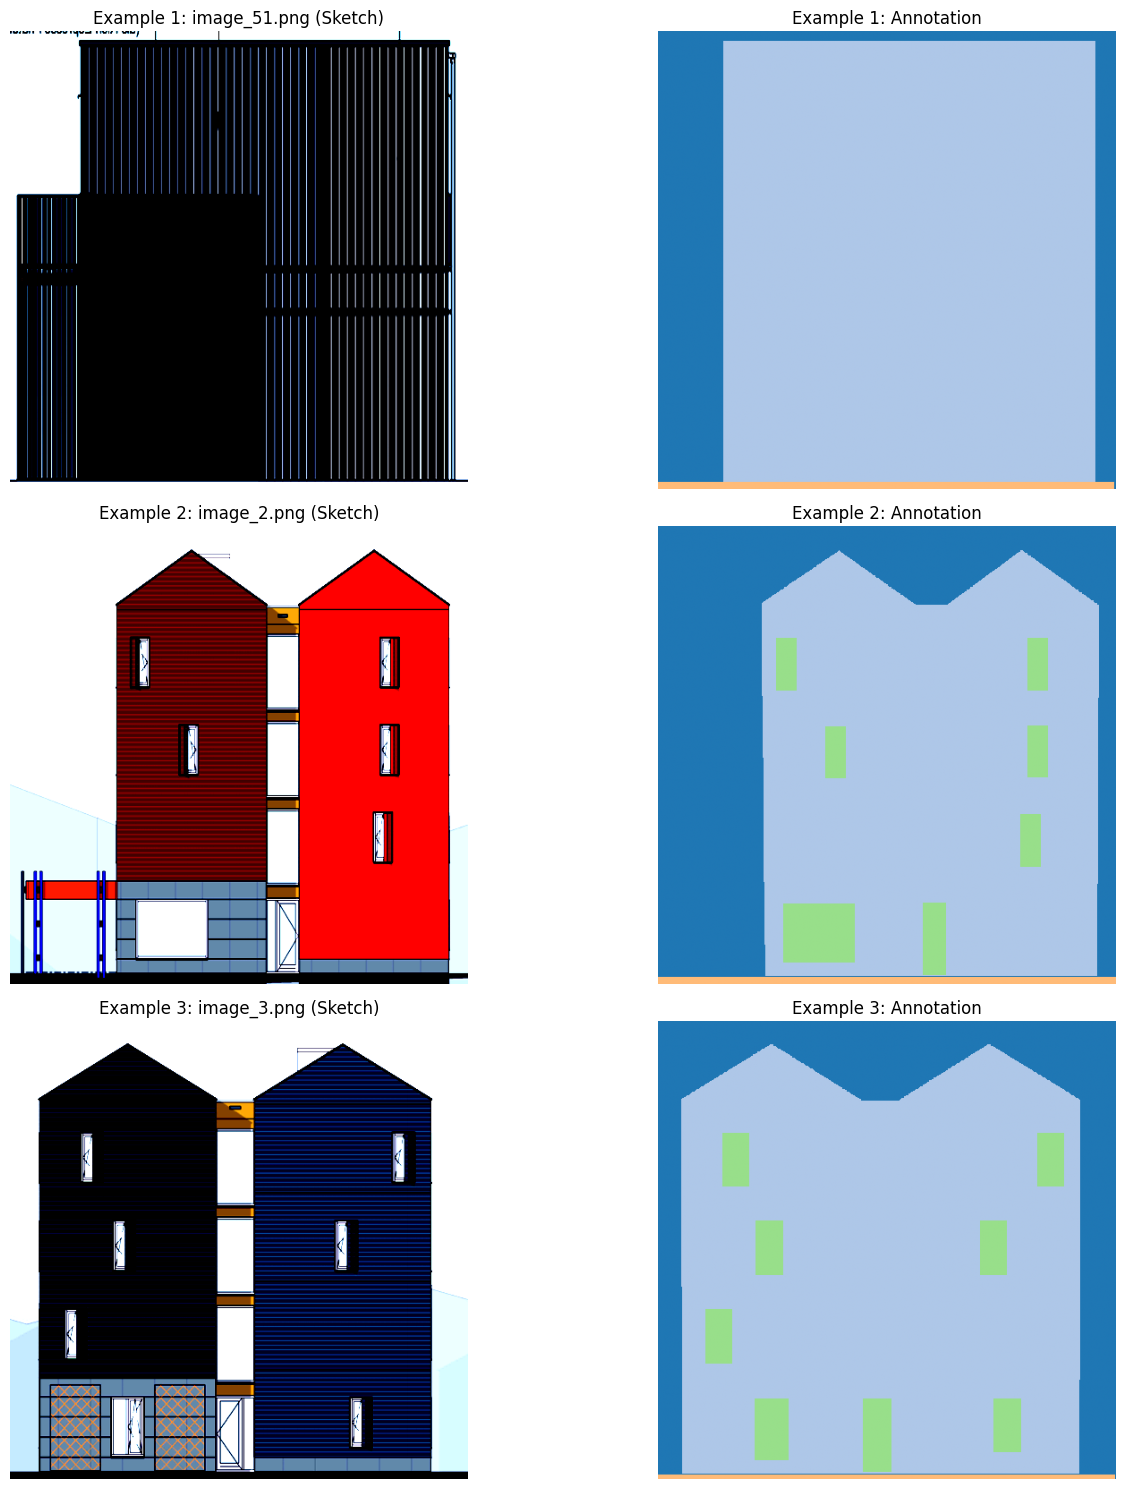

In [7]:
# Visualize Random Examples from the Training Dataset
def visualize_random_examples(dataset, num_examples=3):
    indices = random.sample(range(len(dataset)), num_examples)
    
    plt.figure(figsize=(15, 5 * num_examples))
    for i, idx in enumerate(indices):
        image, annotation = dataset[idx]
        image_name = dataset.image_files[idx]
        
        # Convert image and annotation back to numpy for visualization
        image = image.permute(1, 2, 0).numpy()
        annotation = annotation.numpy()
        
        # Plot image
        plt.subplot(num_examples, 2, 2 * i + 1)
        plt.imshow(image)
        plt.title(f"Example {i+1}: {image_name} (Sketch)")
        plt.axis("off")
        
        # Plot annotation
        plt.subplot(num_examples, 2, 2 * i + 2)
        plt.imshow(annotation, cmap="tab20", vmin=0, vmax=11)
        plt.title(f"Example {i+1}: Annotation")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Visualize random examples from the training dataset
visualize_random_examples(train_dataset, num_examples=3)

In [8]:
# --- Training ---
num_epochs = 10
best_loss = float('inf')

train_losses = []
val_losses = []
val_accuracies = []
val_ious = []

def compute_iou(pred, target, num_classes=12):
    ious = []
    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))  # skip class with no presence
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)  # mean IoU, ignoring NaNs

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, annotations in train_loader:
        images, annotations = images.to(device), annotations.to(device)
        optimizer.zero_grad()
        outputs = model(images)['out']
        loss = criterion(outputs, annotations)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    correct_pixels = 0
    total_pixels = 0
    iou_list = []

    with torch.no_grad():
        for images, annotations in eval_loader:
            images, annotations = images.to(device), annotations.to(device)
            outputs = model(images)['out']
            loss = criterion(outputs, annotations)
            val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct_pixels += (preds == annotations).sum().item()
            total_pixels += annotations.numel()

            for i in range(images.size(0)):
                iou = compute_iou(preds[i], annotations[i])
                iou_list.append(iou)

    val_loss = val_loss / len(eval_loader.dataset)
    val_accuracy = correct_pixels / total_pixels * 100
    val_mean_iou = np.nanmean(iou_list)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_ious.append(val_mean_iou)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}% | Val mIoU: {val_mean_iou:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "deeplabv3_best_model.pth")
        print("Saved best model")

Epoch 1/10 | Train Loss: 1.3670 | Val Loss: 48.2442 | Val Acc: 26.87% | Val mIoU: 0.1324
Saved best model
Epoch 2/10 | Train Loss: 0.5216 | Val Loss: 0.5194 | Val Acc: 82.61% | Val mIoU: 0.5858
Saved best model
Epoch 3/10 | Train Loss: 0.4085 | Val Loss: 0.5585 | Val Acc: 84.99% | Val mIoU: 0.5990
Epoch 4/10 | Train Loss: 0.2955 | Val Loss: 0.3181 | Val Acc: 89.79% | Val mIoU: 0.7041
Saved best model
Epoch 5/10 | Train Loss: 0.2611 | Val Loss: 0.2494 | Val Acc: 91.12% | Val mIoU: 0.7778
Saved best model
Epoch 6/10 | Train Loss: 0.2228 | Val Loss: 0.2668 | Val Acc: 90.74% | Val mIoU: 0.6898
Epoch 7/10 | Train Loss: 0.1875 | Val Loss: 0.2794 | Val Acc: 89.23% | Val mIoU: 0.7150
Epoch 8/10 | Train Loss: 0.1894 | Val Loss: 0.2429 | Val Acc: 90.13% | Val mIoU: 0.7270
Saved best model
Epoch 9/10 | Train Loss: 0.1674 | Val Loss: 0.2728 | Val Acc: 91.93% | Val mIoU: 0.7207
Epoch 10/10 | Train Loss: 0.1869 | Val Loss: 0.3424 | Val Acc: 87.51% | Val mIoU: 0.7399


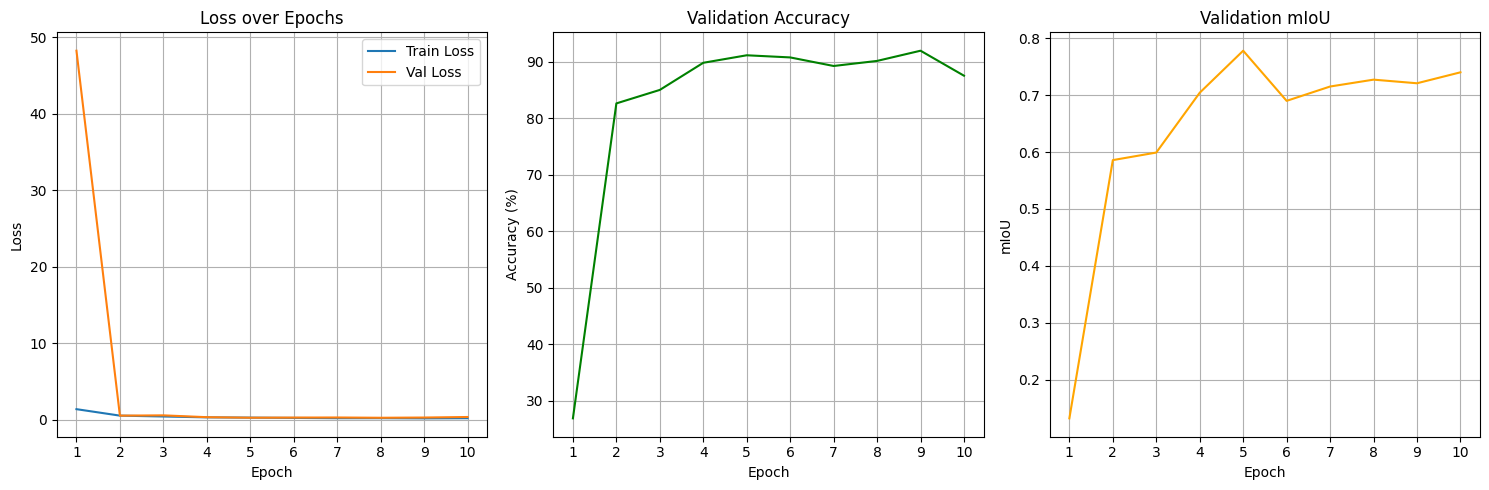

In [9]:
# --- Plot Training Metrics ---
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid(True)
plt.xticks(epochs)  # Set integer epoch ticks

plt.subplot(1, 3, 2)
plt.plot(epochs, val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.grid(True)
plt.xticks(epochs)  # Set integer epoch ticks

plt.subplot(1, 3, 3)
plt.plot(epochs, val_ious, label="Val Mean IoU", color="orange")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title("Validation mIoU")
plt.grid(True)
plt.xticks(epochs)  # Set integer epoch ticks

plt.tight_layout()
plt.show()

## Testing model on test set

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


Test Loss: 0.2156
Test Accuracy: 91.81%


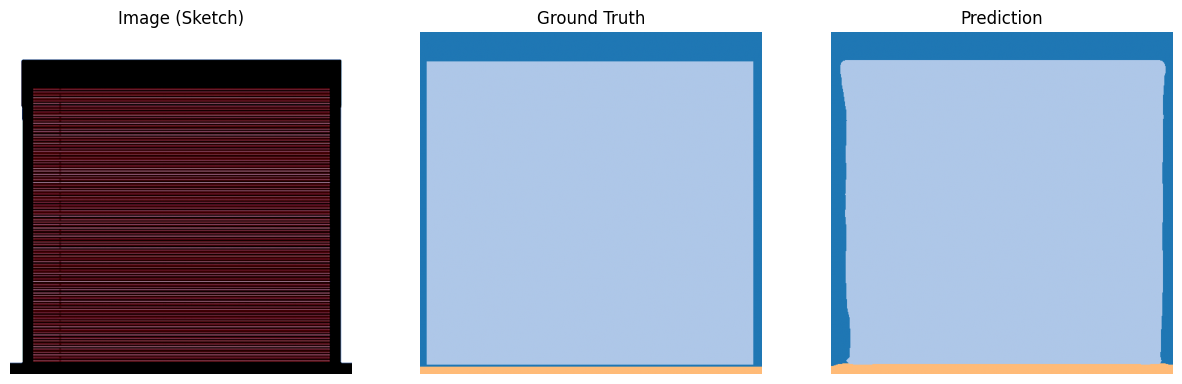

In [10]:
# Testing
model.load_state_dict(torch.load("deeplabv3_best_model.pth"))
model.eval()
test_loss = 0.0
correct_pixels = 0
total_pixels = 0

with torch.no_grad():
    for images, annotations in test_loader:
        images, annotations = images.to(device), annotations.to(device)
        outputs = model(images)['out']
        loss = criterion(outputs, annotations)
        test_loss += loss.item() * images.size(0)
        
        # Calculate accuracy
        preds = torch.argmax(outputs, dim=1)
        correct_pixels += (preds == annotations).sum().item()
        total_pixels += annotations.numel()

test_loss = test_loss / len(test_loader.dataset)
accuracy = correct_pixels / total_pixels * 100

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

# Visualize a Test Prediction
model.eval()
with torch.no_grad():
    images, annotations = next(iter(test_loader))
    images, annotations = images.to(device), annotations.to(device)
    outputs = model(images)['out']
    preds = torch.argmax(outputs, dim=1)
    
    # Plot
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(images[0].cpu().permute(1, 2, 0).numpy())
    plt.title("Image (Sketch)")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(annotations[0].cpu().numpy(), cmap="tab20", vmin=0, vmax=11)
    plt.title("Ground Truth")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(preds[0].cpu().numpy(), cmap="tab20", vmin=0, vmax=11)
    plt.title("Prediction")
    plt.axis("off")
    
    plt.show()

## Test on unseen data

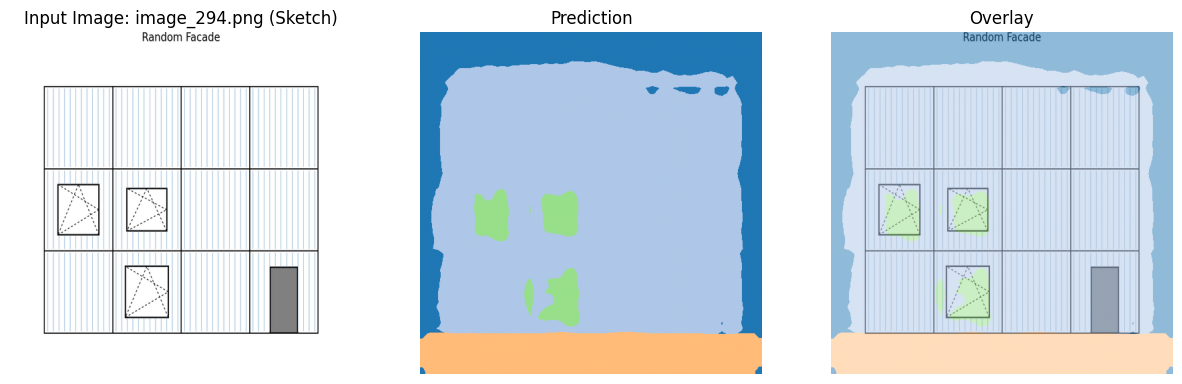

In [11]:
# Specify the path to the image
image_path = "../data/dump/image_294.png"

# Load and preprocess the image
image = Image.open(image_path).convert("RGB")
# image = pencil_sketch(image)  # Apply pencil sketch
resize_size = (512, 512)
image = image.resize(resize_size, Image.Resampling.LANCZOS)
image_np = np.array(image)  # Keep the sketched image for overlay
image = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0
image = image.unsqueeze(0).to(device)

# Perform inference
model.eval()
with torch.no_grad():
    output = model(image)['out']
    prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Visualize the input image, prediction, and overlay
plt.figure(figsize=(15, 5))

# Input Image
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title(f"Input Image: {os.path.basename(image_path)} (Sketch)")
plt.axis("off")

# Prediction
plt.subplot(1, 3, 2)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11)
plt.title("Prediction")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(image_np)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

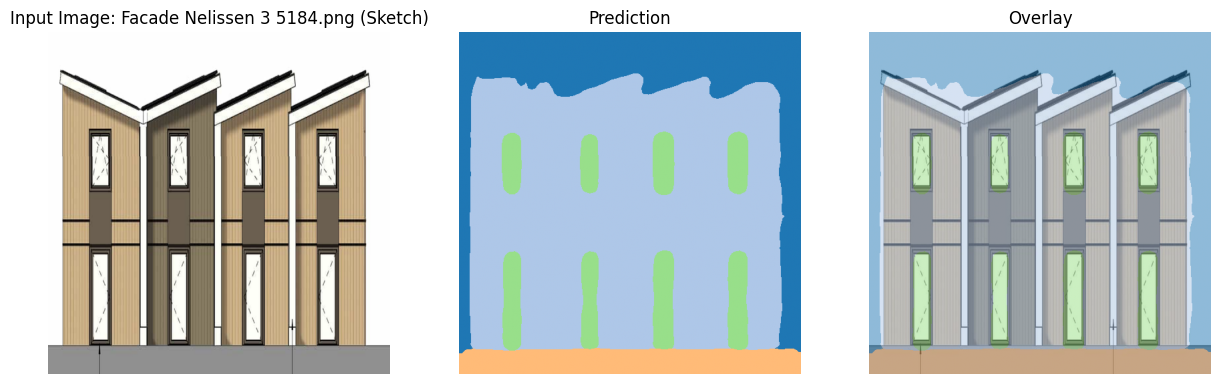

In [12]:
# Specify the path to the image
image_path = "../data/dump/Facade Nelissen 3 5184.png"

# Load and preprocess the image
image = Image.open(image_path).convert("RGB")
# image = pencil_sketch(image)  # Apply pencil sketch
resize_size = (512, 512)
image = image.resize(resize_size, Image.Resampling.LANCZOS)
image_np = np.array(image)  # Keep the sketched image for overlay
image = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0
image = image.unsqueeze(0).to(device)

# Perform inference
model.eval()
with torch.no_grad():
    output = model(image)['out']
    prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Visualize the input image, prediction, and overlay
plt.figure(figsize=(15, 5))

# Input Image
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title(f"Input Image: {os.path.basename(image_path)} (Sketch)")
plt.axis("off")

# Prediction
plt.subplot(1, 3, 2)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11)
plt.title("Prediction")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(image_np)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

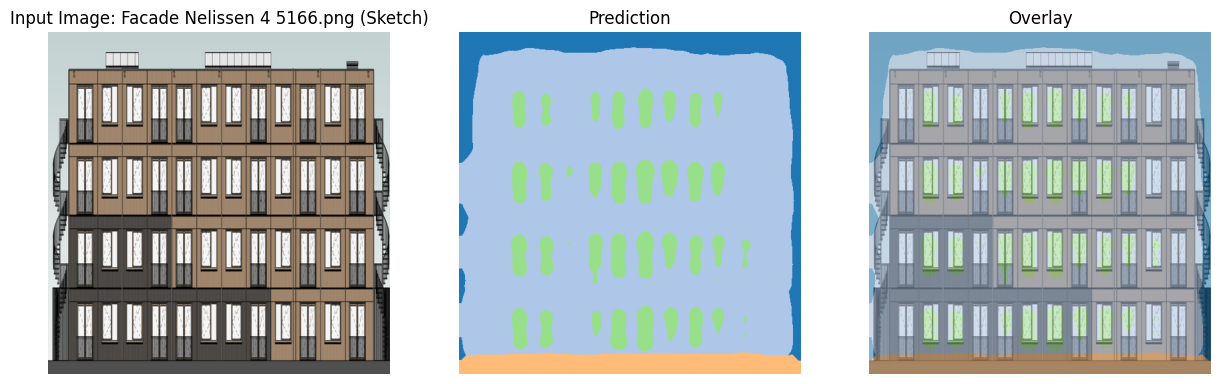

In [13]:
# Specify the path to the image
image_path = "../data/dump/Facade Nelissen 4 5166.png"

# Load and preprocess the image
image = Image.open(image_path).convert("RGB")
# image = pencil_sketch(image)  # Apply pencil sketch
resize_size = (512, 512)
image = image.resize(resize_size, Image.Resampling.LANCZOS)
image_np = np.array(image)  # Keep the sketched image for overlay
image = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0
image = image.unsqueeze(0).to(device)

# Perform inference
model.eval()
with torch.no_grad():
    output = model(image)['out']
    prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Visualize the input image, prediction, and overlay
plt.figure(figsize=(15, 5))

# Input Image
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title(f"Input Image: {os.path.basename(image_path)} (Sketch)")
plt.axis("off")

# Prediction
plt.subplot(1, 3, 2)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11)
plt.title("Prediction")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(image_np)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()